In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
dataset_path = '/content/drive/MyDrive/Dataset/Lung Cancer Prediction - IEEE Jordan AI Modeling Hackathon 1.0/train'
img_size = (224, 224)

data = []
labels = []
class_names = os.listdir(dataset_path)

for label in class_names:
    folder = os.path.join(dataset_path, label)
    if not os.path.isdir(folder):
        continue
    for img_file in glob.glob(os.path.join(folder, "*.jpg")):  # or png
        img = load_img(img_file, target_size=img_size)
        img_array = img_to_array(img) / 255.0
        data.append(img_array)
        labels.append(label)

# Convert to arrays
X = np.array(data)
y = np.array(labels)

print(f"Total images: {len(X)}")

Total images: 877


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode string labels to numbers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Split data into train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(X, y_cat, test_size=0.3, random_state=42, stratify=y_cat)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (613, 224, 224, 3), Val: (132, 224, 224, 3), Test: (132, 224, 224, 3)


CNN

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.4624 - loss: 1.5622 - val_accuracy: 0.6515 - val_loss: 0.8346
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.6636 - loss: 0.8307 - val_accuracy: 0.6970 - val_loss: 0.6629
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7744 - loss: 0.5635 - val_accuracy: 0.6970 - val_loss: 0.6373
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8321 - loss: 0.4300 - val_accuracy: 0.9015 - val_loss: 0.3110
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9144 - loss: 0.2495 - val_accuracy: 0.9242 - val_loss: 0.2204
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9420 - loss: 0.1588 - val_accuracy: 0.9167 - val_loss: 0.1853
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.9656 - loss: 0.0991 - val_accuracy: 0.9848 - val_loss: 0.1287
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.9819 - loss: 0.0724 - val_accuracy: 0.9545 - val_loss:

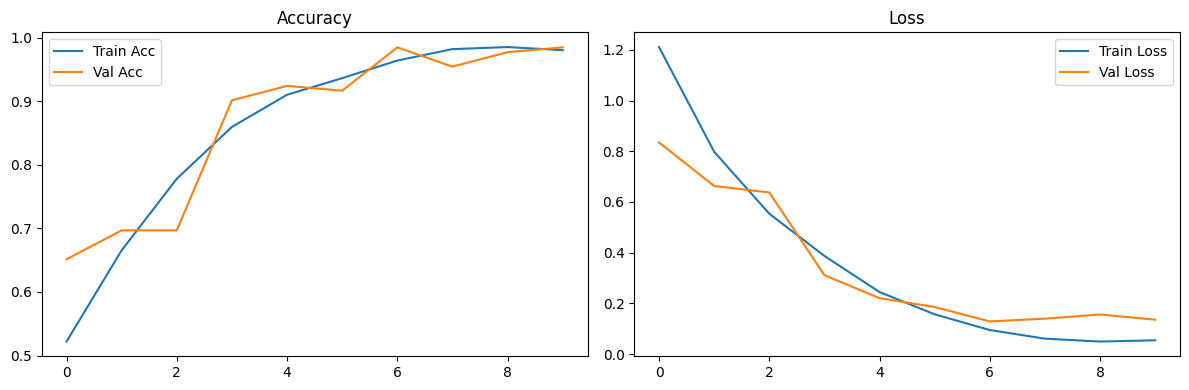

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 604ms/step - accuracy: 0.9828 - loss: 0.1822
Test Accuracy: 0.98


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 598ms/step


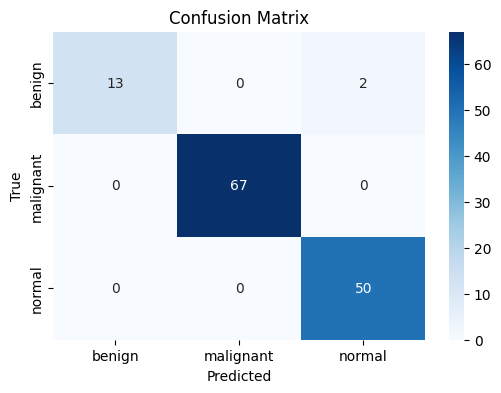

              precision    recall  f1-score   support

      benign       1.00      0.87      0.93        15
   malignant       1.00      1.00      1.00        67
      normal       0.96      1.00      0.98        50

    accuracy                           0.98       132
   macro avg       0.99      0.96      0.97       132
weighted avg       0.99      0.98      0.98       132



In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred_classes, target_names=encoder.classes_))
